In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#sns.set(style="whitegrid")

In [ ]:
# Load dataset
df = pd.read_excel("3 year 21-22-23 SAC Agg.xlsx")

# df.head()
# df.columns
# df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 31 columns):
 #   Column                                                  Non-Null Count  Dtype
---  ------                                                  --------------  -----
 0   State                                                   153 non-null    str  
 1   Year                                                    153 non-null    int64
 2   Organizations                                           153 non-null    int64
 3   Intake - Relinquished By Owner Total-Feline             153 non-null    int64
 4   Intake - Stray At Large Total-Feline                    153 non-null    int64
 5   Intake - Transferred In Total-Feline                    153 non-null    int64
 6   Intake - Owner Intended Euthanasia Total-Feline         153 non-null    int64
 7   Intakes - Other Intakes Total-Feline                    153 non-null    int64
 8   Live Outcome - Adoption Total-Feline                    153 non-null   

In [4]:
df["intake_total"] = (
    df["Intake - Relinquished By Owner Total-Feline"] +
    df["Intake - Stray At Large Total-Feline"] +
    df["Intake - Transferred In Total-Feline"] +
    df["Intake - Owner Intended Euthanasia Total-Feline"] +
    df["Intakes - Other Intakes Total-Feline"] +
    df["Intake - Relinquished By Owner Total-Canine"] +
    df["Intake - Stray At Large Total-Canine"] +
    df["Intake - Transferred In Total-Canine"] +
    df["Intake - Owner Intended Euthanasia Total-Canine"] +
    df["Intakes - Other Intakes Total-Canine"]
)

In [5]:
df["outcome_total"] = (
    df["Live Outcome - Adoption Total-Feline"] +
    df["Live Outcome - Returned To Owner Total-Feline"] +
    df["Live Outcome - Returned To Field Total-Feline"] +
    df["Live Outcome - Transferred Out Total-Feline"] +
    df["Live outcome - Other Live Outcome Total-Feline"] +
    df["Other Outcome - Died In Care Total-Feline"] +
    df["Other Outcome - Lost In Care Total-Feline"] +
    df["Other Outcome - Owner Intended Euthanasia Total-Feline"] +
    df["Other Outcome - Shelter Euthanasia Total-Feline"] +
    df["Live Outcome - Adoption Total-Canine"] +
    df["Live Outcome - Returned To Owner Total-Canine"] +
    df["Live Outcome - Returned To Field Total-Canine"] +
    df["Live Outcome - Transferred Out Total-Canine"] +
    df["Live outcome - Other Live Outcome Total-Canine"] +
    df["Other Outcome - Died In Care Total-Canine"] +
    df["Other Outcome - Lost In Care Total-Canine"] +
    df["Other Outcome - Owner Intended Euthanasia Total-Canine"] +
    df["Other Outcome - Shelter Euthanasia Total-Canine"]
)

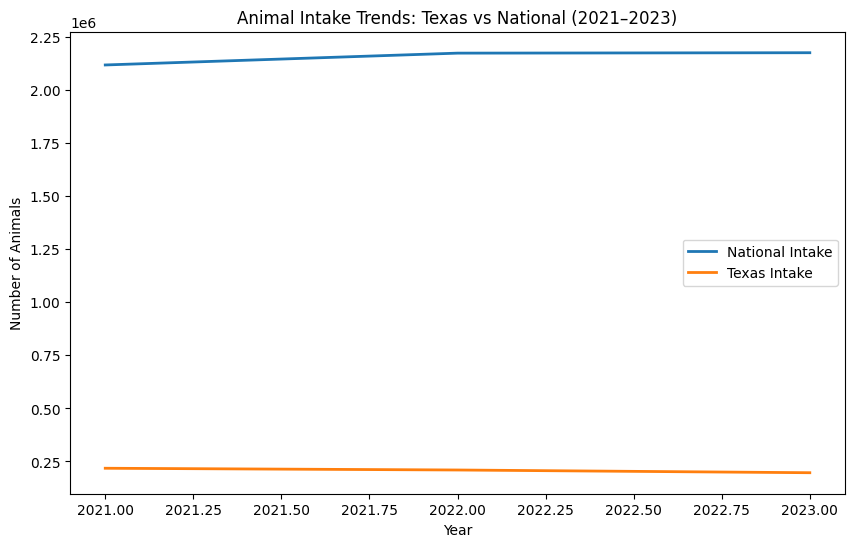

In [6]:
# Aggregate national totals by year
national = df.groupby("Year")[["intake_total", "outcome_total"]].sum().reset_index()

# Filter Texas
texas = df[df["State"] == "TX"].groupby("Year")[["intake_total", "outcome_total"]].sum().reset_index()

# Plot
plt.figure(figsize=(10,6))

plt.plot(national["Year"], national["intake_total"], label="National Intake", linewidth=2)
plt.plot(texas["Year"], texas["intake_total"], label="Texas Intake", linewidth=2)

plt.title("Animal Intake Trends: Texas vs National (2021–2023)")
plt.xlabel("Year")
plt.ylabel("Number of Animals")
plt.legend()

plt.show()

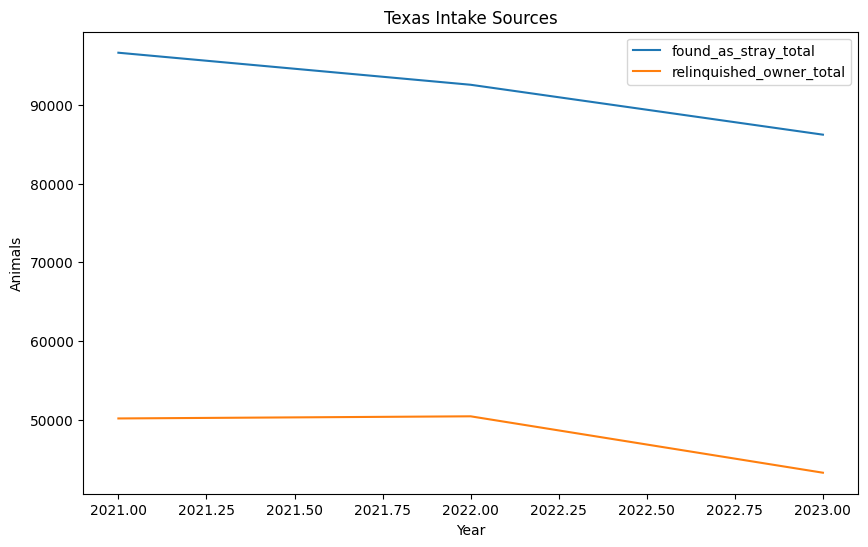

In [7]:
df["found_as_stray_total"] = (
    df["Intake - Stray At Large Total-Feline"] +
    df["Intake - Stray At Large Total-Canine"]
)

df["relinquished_owner_total"] = (
    df["Intake - Relinquished By Owner Total-Feline"] +
    df["Intake - Relinquished By Owner Total-Canine"]
)

texas_trends = df[df["State"] == "TX"].groupby("Year")[["found_as_stray_total", "relinquished_owner_total"]].sum()

texas_trends.plot(kind="line", figsize=(10,6), title="Texas Intake Sources")
plt.ylabel("Animals")
plt.show()

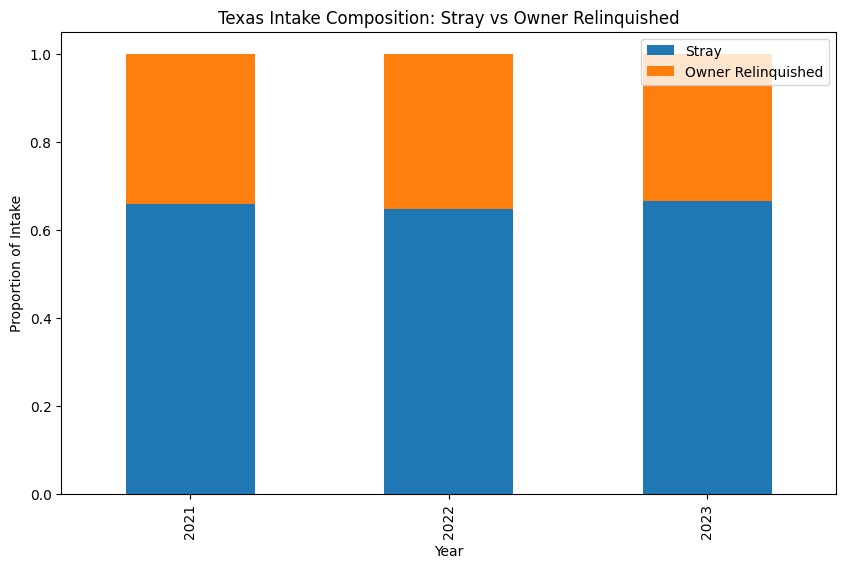

In [8]:
# Aggregate
national = df.groupby("Year")[["found_as_stray_total", "relinquished_owner_total"]].sum()
texas = df[df["State"] == "TX"].groupby("Year")[["found_as_stray_total", "relinquished_owner_total"]].sum()

# Convert to percentages
national_pct = national.div(national.sum(axis=1), axis=0)
texas_pct = texas.div(texas.sum(axis=1), axis=0)

# Plot Texas
texas_pct.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Texas Intake Composition: Stray vs Owner Relinquished")
plt.ylabel("Proportion of Intake")
plt.xlabel("Year")

plt.legend(["Stray", "Owner Relinquished"])
plt.show()

In [9]:
state_intake = df.groupby("State")["intake_total"].sum().reset_index()

In [ ]:
fig = px.choropleth(
    state_intake,
    locations="State",             
    locationmode="USA-states",
    color="intake_total",
    scope="usa",
    color_continuous_scale="Reds",
    labels={"intake_total": "Total Intake"},
    title="Total Animal Intake by State (2021–2023)"
)

fig.show()

In [15]:
df["euthanasia_total"] = (
    df["Other Outcome - Shelter Euthanasia Total-Feline"] +
    df["Other Outcome - Shelter Euthanasia Total-Canine"]
)
df["euthanasia_rate"] = df["euthanasia_total"] / df["intake_total"]

In [13]:
state_euth = df.groupby("State")[["euthanasia_total", "intake_total"]].sum()

state_euth["euthanasia_rate"] = (
    state_euth["euthanasia_total"] / state_euth["intake_total"]
)

In [1]:
fig = px.choropleth(
    state_euth,
    locations="State",
    locationmode="USA-states",
    color="euthanasia_rate",
    scope="usa",
    color_continuous_scale="OrRd",
    labels={"euthanasia_rate": "Euthanasia Rate"},
    title="Euthanasia Rate by State (2021–2023)"
)

fig.show()

NameError: name 'px' is not defined